# Rain in Australia

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
%matplotlib inline

In [103]:
df = pd.read_csv("weatherAUS.csv")

In [104]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [105]:
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [106]:
df.shape

(145460, 23)

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [108]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [109]:
df.select_dtypes(include="str").nunique()

Date            3436
Location          49
WindGustDir       16
WindDir9am        16
WindDir3pm        16
RainToday          2
RainTomorrow       2
dtype: int64

In [110]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
 
pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct}).query("n_missing > 0")

,n_missing,pct_missing
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [111]:
df.groupby("Location").apply(lambda g: g.isna().mean() * 100).round(2)[
    ["Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"]
]

,Evaporation,Sunshine,Cloud9am,Cloud3pm
Location,,,,
Adelaide,46.63,44.60,100.00,100.00
Albany,9.54,17.11,1.25,23.39
Albury,100.00,100.00,57.60,53.06
AliceSprings,7.07,17.11,10.99,11.88
BadgerysCreek,100.00,100.00,100.00,100.00
Ballarat,100.00,100.00,17.96,34.47
Bendigo,61.02,100.00,31.84,25.39
Brisbane,0.60,1.53,0.03,0.06
Cairns,12.17,15.66,6.81,7.57


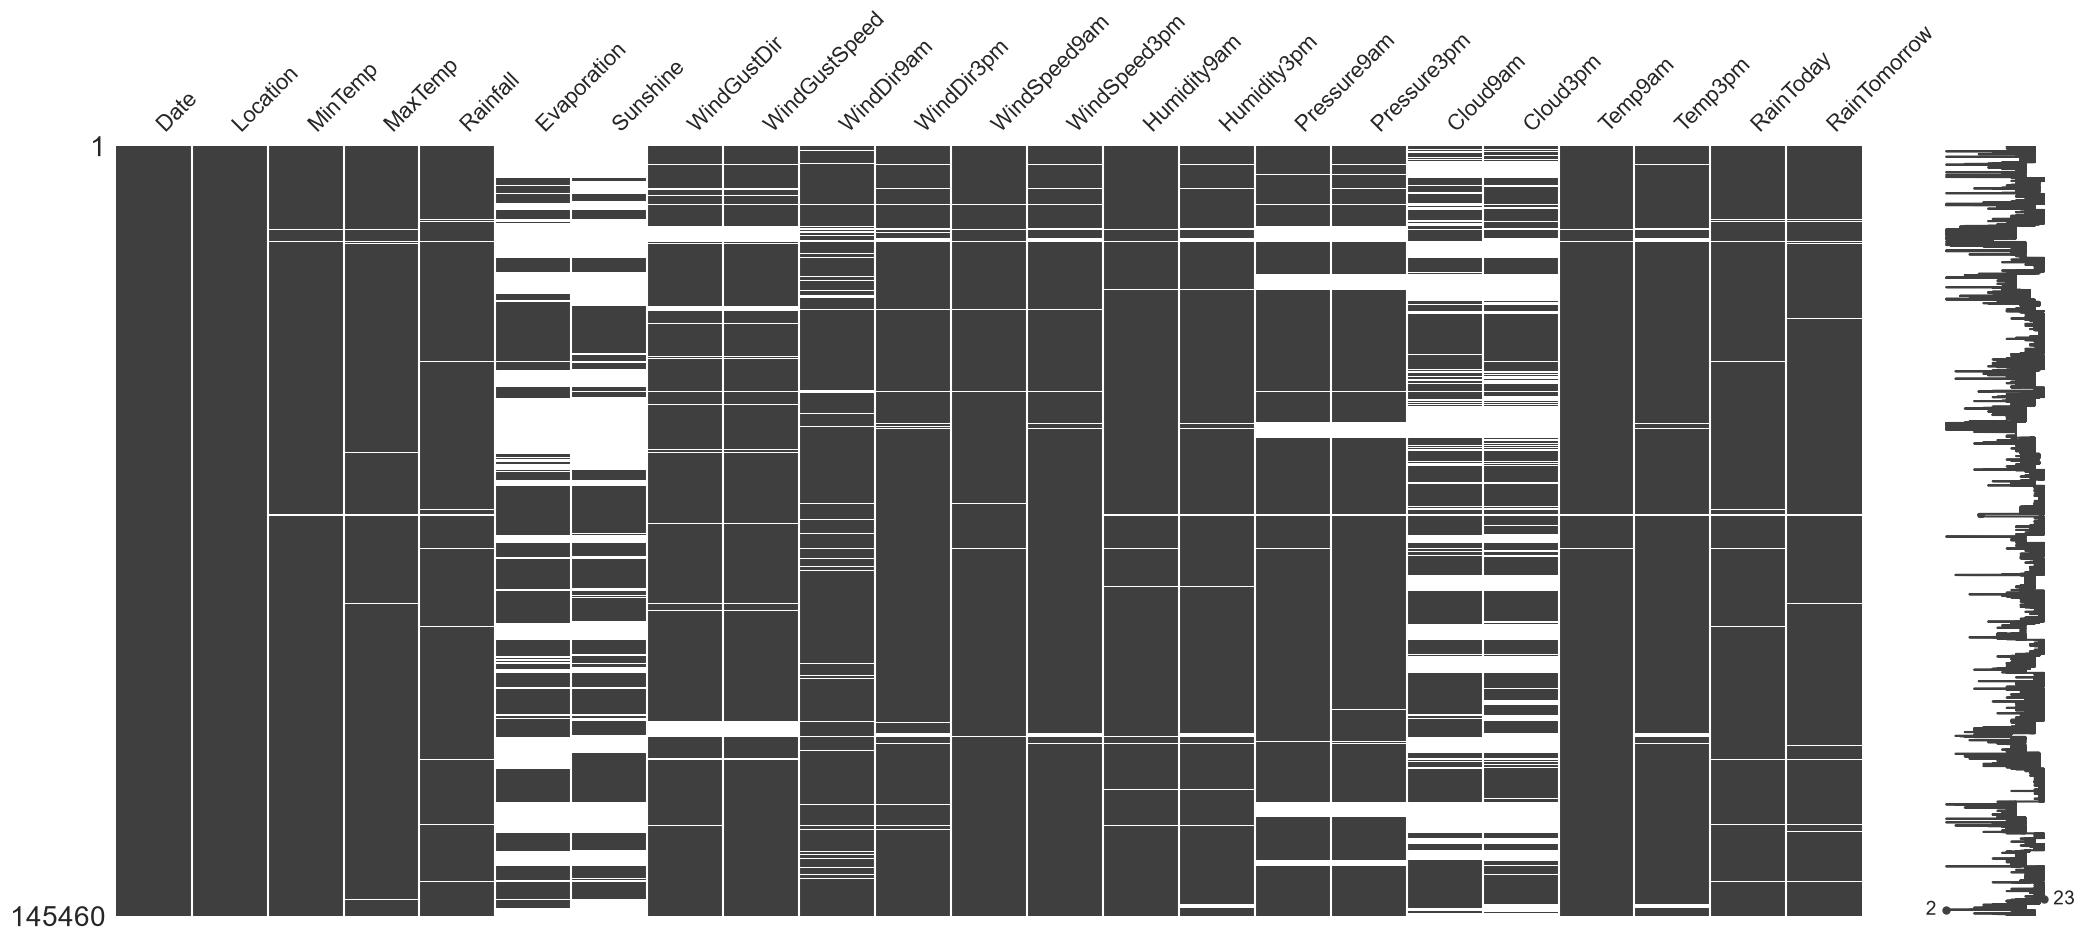

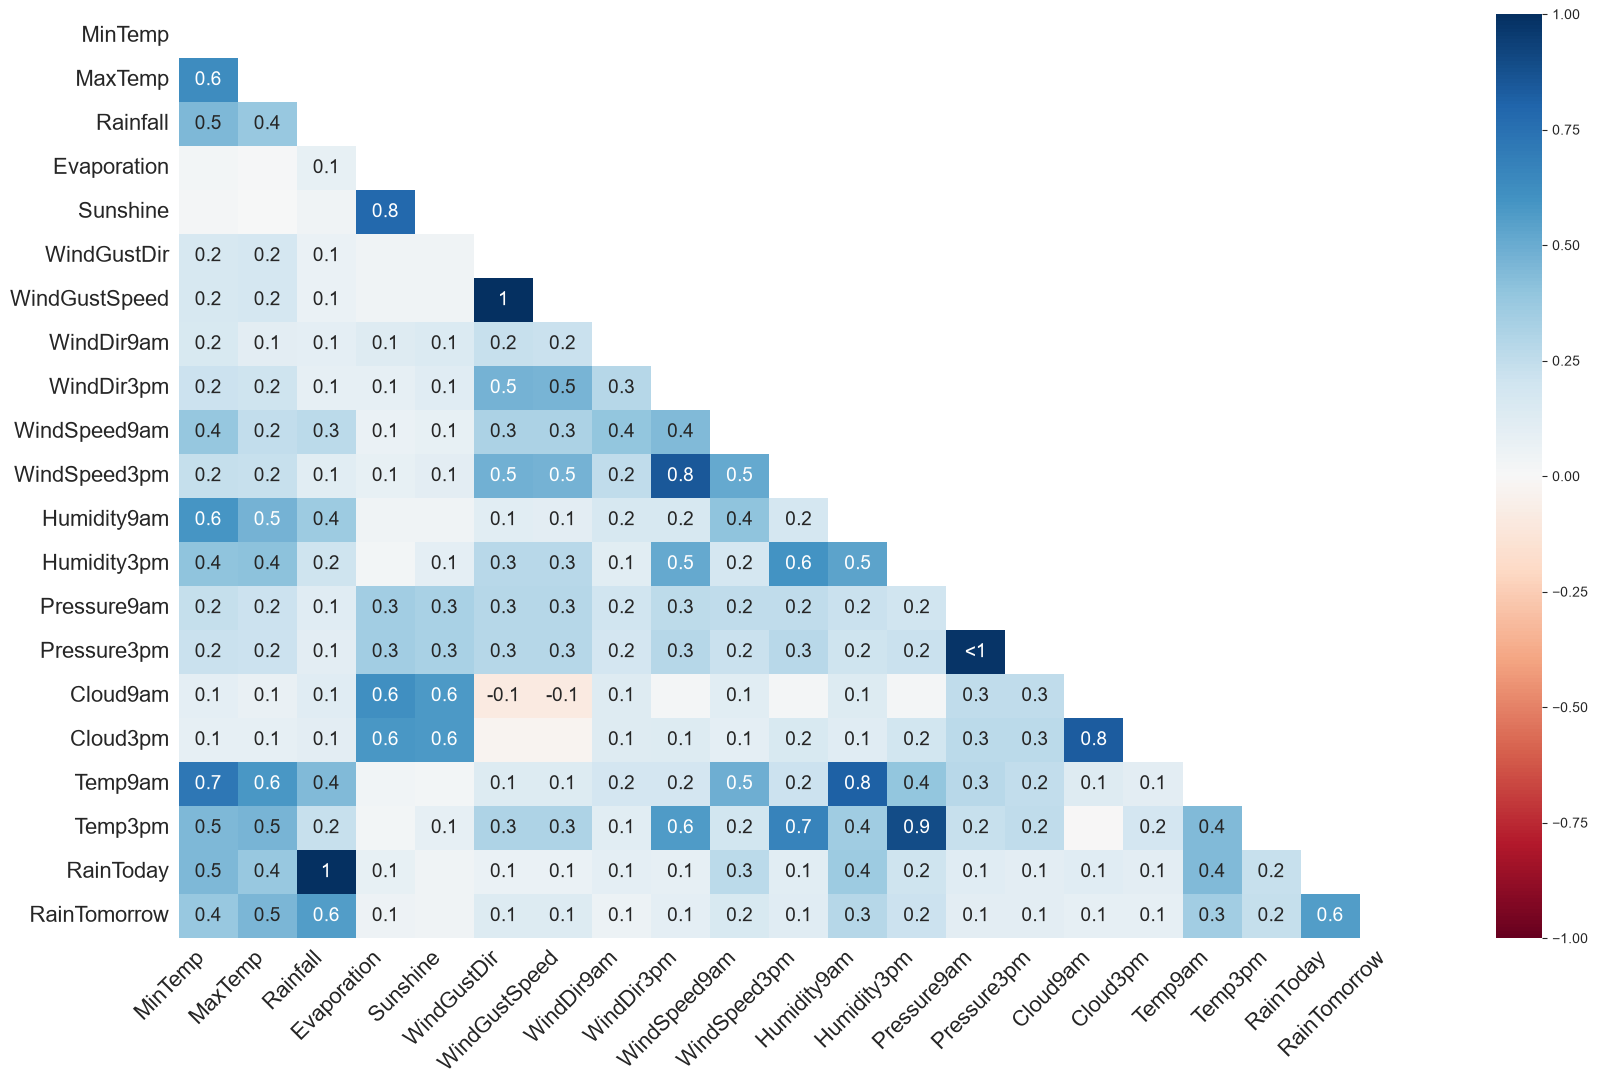

In [112]:
import missingno as msno

msno.matrix(df)
plt.show()

msno.heatmap(df)
plt.show()

In [113]:
before = len(df)
df = df.dropna(subset=["RainTomorrow", "RainToday"])
print(f"Удалено строк: {before - len(df)} ({(before - len(df)) / before * 100:.1f}%)")

Удалено строк: 4673 (3.2%)


In [114]:
df['RainTomorrow'].isnull().sum()

np.int64(0)

In [115]:
cols_with_missing = df.columns[df.isna().any()].tolist()

for col in cols_with_missing:
    df[f"{col}_was_missing"] = df[col].isna().astype(int)
 
df[[c for c in df.columns if "_was_missing" in c]].sum().sort_values(ascending=False)

Sunshine_was_missing         66805
Evaporation_was_missing      59694
Cloud3pm_was_missing         56094
Cloud9am_was_missing         52625
Pressure3pm_was_missing      13769
Pressure9am_was_missing      13743
WindDir9am_was_missing        9660
WindGustDir_was_missing       9163
WindGustSpeed_was_missing     9105
WindDir3pm_was_missing        3670
Humidity3pm_was_missing       3501
Temp3pm_was_missing           2624
WindSpeed3pm_was_missing      2531
Humidity9am_was_missing       1517
WindSpeed9am_was_missing      1055
Temp9am_was_missing            656
MinTemp_was_missing            468
MaxTemp_was_missing            307
dtype: int64

In [116]:
df["Date"] = pd.to_datetime(df["Date"])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [117]:
df.drop('Date', axis=1, inplace=True)

In [119]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

df["Season"] = df["Month"].apply(month_to_season)

In [97]:
target_col = "RainTomorrow"
flag_cols = [c for c in df.columns if c.endswith("_was_missing")]
cat_cols = df.select_dtypes(include="str").columns.difference([target_col]).tolist()
num_cols = df.select_dtypes(include=np.number).columns.difference(flag_cols).tolist()

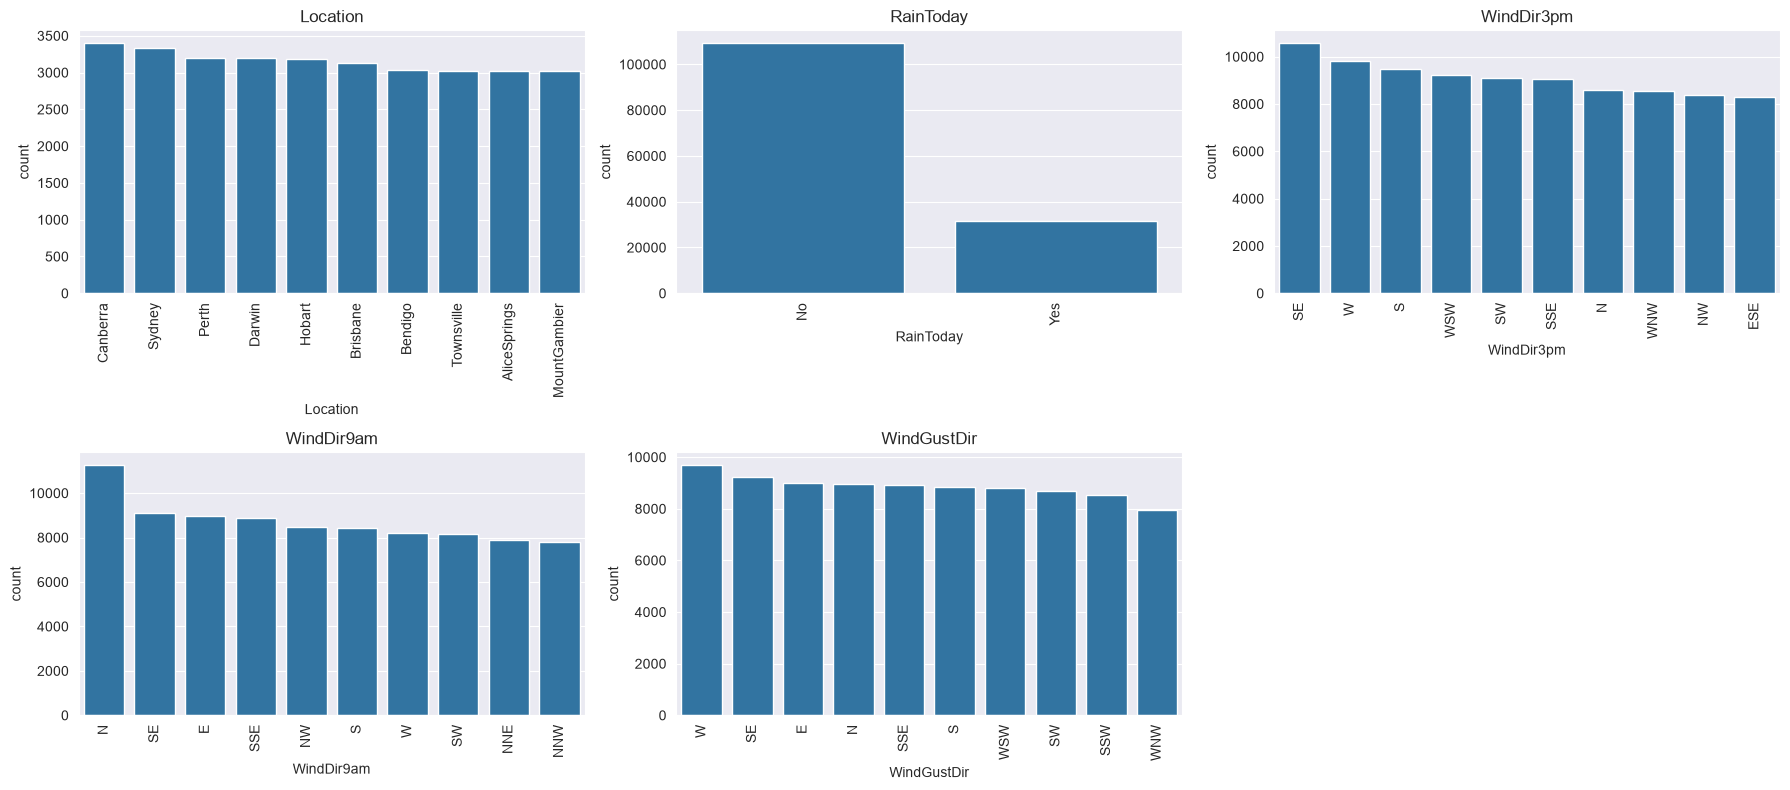

In [64]:
n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top_categories = df[col].value_counts().head(10).index  
    sns.countplot(data=df, x=col, order=top_categories, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=90)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j]) 

plt.tight_layout()
plt.show()

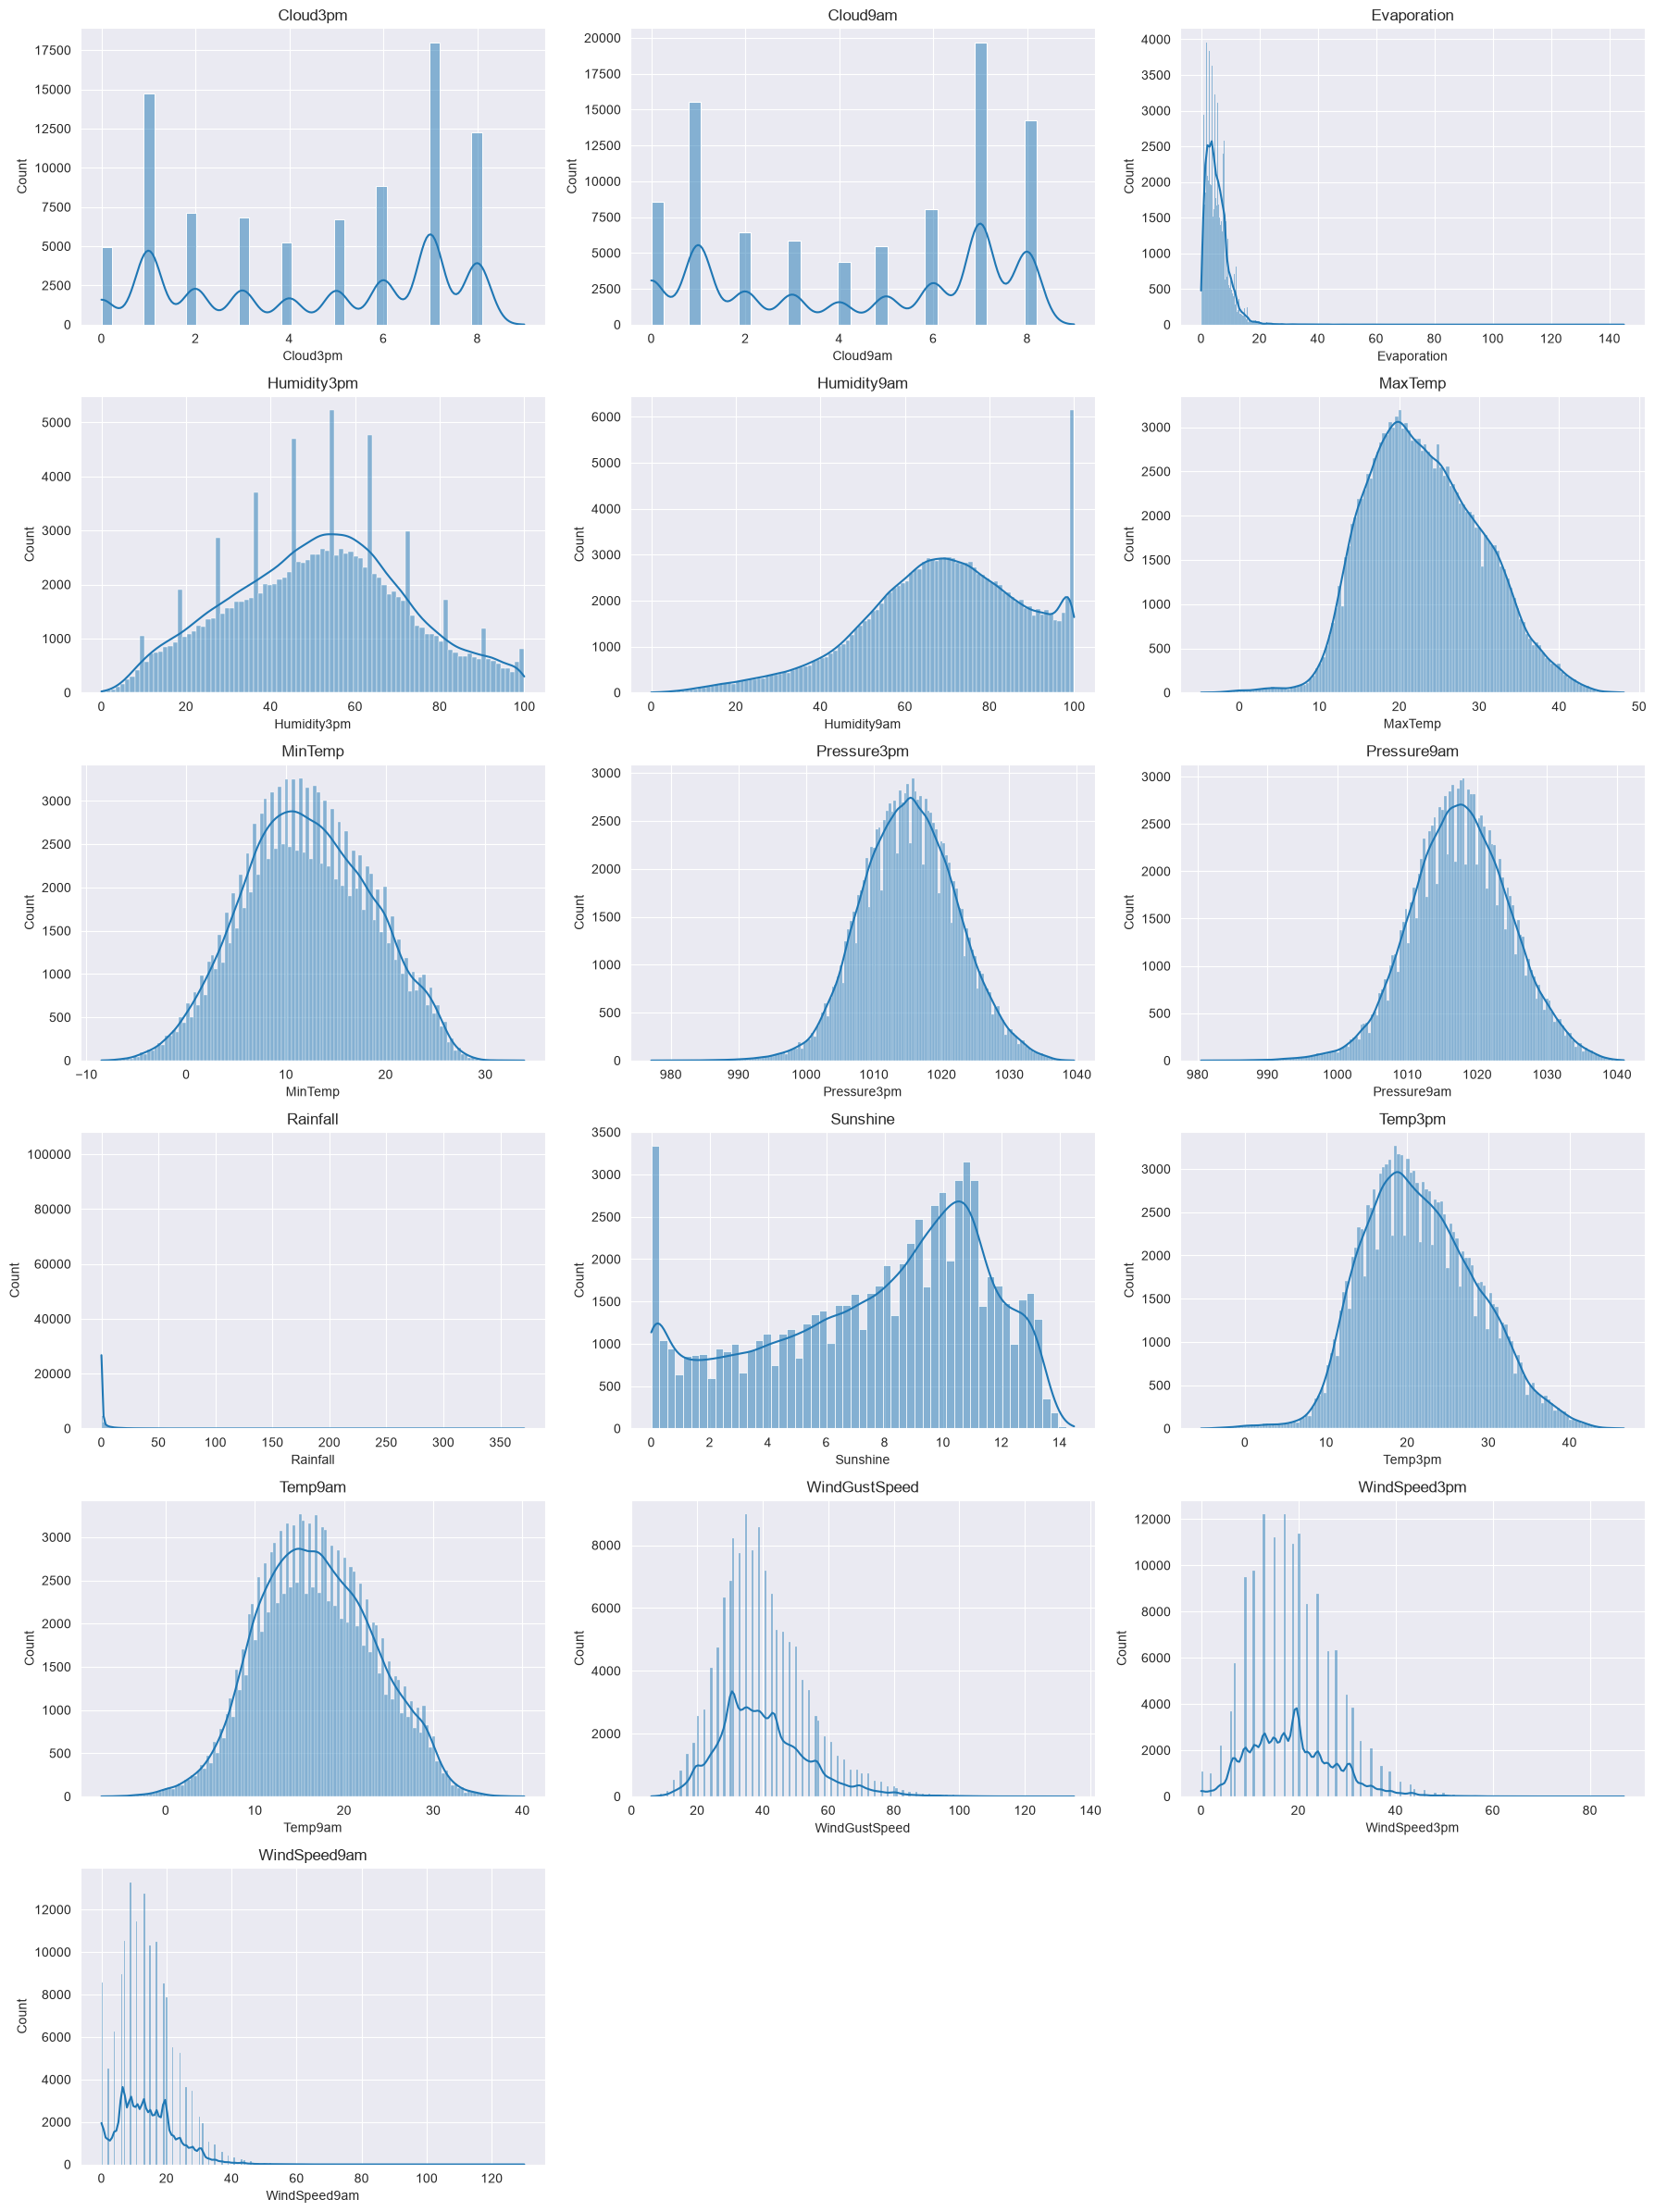

In [71]:
n_cols = 3
n_rows = -(-len(num_cols) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j]) 

plt.tight_layout()
plt.show()

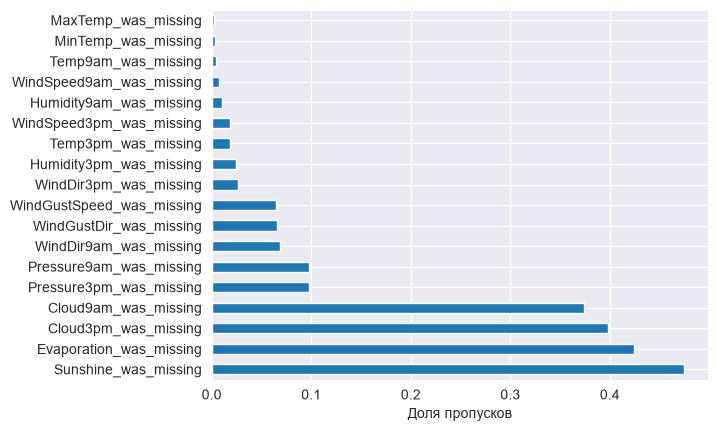

In [58]:
df[flag_cols].mean().sort_values(ascending=False).plot(kind="barh")
plt.xlabel("Доля пропусков")
plt.show()